Exercise 2 optimization results
Optimal S_P = 110.114 g glucose/L
Maximum production rate = 137.599 g product/h

Production rates near the optimum:
S_P =   95.0 g/L -> production rate =  118.708 g/h
S_P =  100.0 g/L -> production rate =  124.960 g/h
S_P =  105.0 g/L -> production rate =  131.211 g/h
S_P =  108.0 g/L -> production rate =  134.962 g/h
S_P =  109.0 g/L -> production rate =  136.212 g/h
S_P =  110.0 g/L -> production rate =  137.462 g/h
S_P =  110.1 g/L -> production rate =  137.587 g/h
S_P =  111.0 g/L -> production rate =   43.573 g/h
S_P =  112.0 g/L -> production rate =   27.243 g/h
S_P =  115.0 g/L -> production rate =   13.609 g/h


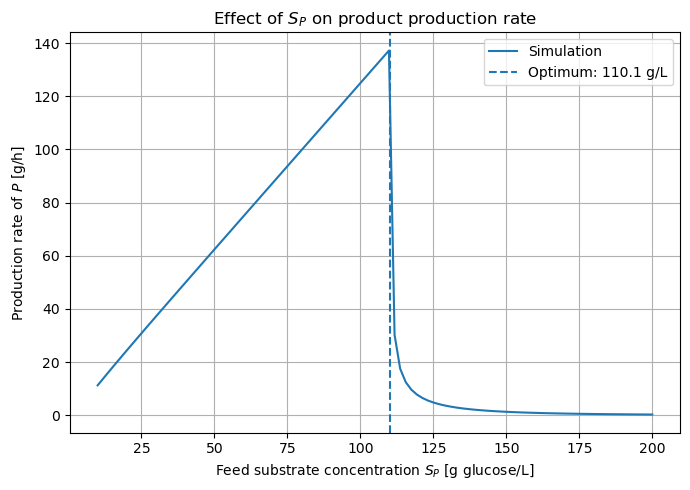

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

mu_max = 0.3
K_S = 0.8         
K_I = 100.0

Y_XS = 0.45
Y_XP = 0.15

S0 = 80.0
F_I = 0.2
F_P = 0.5
F_H = 2.5

t_initiation = 1.0 
t_processing = 5.0
t_harvesting = 1.0
n_cycles = 10

V0 = 0.85
X0 = 30.0
S_initial = 0.0 
P_initial = 0.0

def mu(S):
    """
    Specific growth rate with substrate inhibition.
    S is glucose concentration in g/L.
    """
    S = max(S, 0.0)
    return mu_max * S / (K_S + S + (S**2 / K_I))

def reactor_odes(t, y, phase, S_P):
    """
    State vector:
    y[0] = N_X = mass of cells, g
    y[1] = N_S = mass of substrate, g
    y[2] = N_P = mass of product, g
    y[3] = V   = reactor volume, L
    y[4] = H_P = cumulative harvested product, g
    y[5] = G_P = cumulative generated product, g
    """

    N_X, N_S, N_P, V, H_P, G_P = y

    V = max(V, 1e-12)

    X = N_X / V
    S = N_S / V
    P = N_P / V

    mu_val = mu(S)

    cell_growth = mu_val * N_X
    substrate_consumption = cell_growth / Y_XS
    product_generation = cell_growth / Y_XP

    if phase == "initiation":
        F_in = F_I
        S_in = S0
        F_out = 0.0

    elif phase == "processing":
        F_in = F_P
        S_in = S_P
        F_out = 0.0

    elif phase == "harvesting":
        F_in = 0.0
        S_in = 0.0
        F_out = F_H

    else:
        raise ValueError("Unknown phase")

    dN_Xdt = cell_growth - F_out * X
    dN_Sdt = F_in * S_in - substrate_consumption - F_out * S
    dN_Pdt = product_generation - F_out * P
    dVdt = F_in - F_out

    dH_Pdt = F_out * P

    dG_Pdt = product_generation

    return [dN_Xdt, dN_Sdt, dN_Pdt, dVdt, dH_Pdt, dG_Pdt]


def integrate_phase(y0, t0, duration, phase, S_P):
    """
    Integrates one phase of the fed-batch operation.
    """

    sol = solve_ivp(
        fun=lambda t, y: reactor_odes(t, y, phase, S_P),
        t_span=(t0, t0 + duration),
        y0=y0,
        method="BDF",
        rtol=1e-8,
        atol=1e-10
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol


def simulate_process(S_P, save_profiles=False):
    """
    Simulates:
    - initiation phase
    - 10 processing/harvesting cycles

    Returns production rate during the 10th cycle.
    """

    N_X0 = X0 * V0
    N_S0 = S_initial * V0
    N_P0 = P_initial * V0

    y = np.array([N_X0, N_S0, N_P0, V0, 0.0, 0.0])
    t = 0.0

    all_t = []
    all_y = []

    cycle_results = []

    sol = integrate_phase(y, t, t_initiation, "initiation", S_P)
    y = sol.y[:, -1]
    t = sol.t[-1]

    if save_profiles:
        all_t.append(sol.t)
        all_y.append(sol.y)

    for cycle in range(1, n_cycles + 1):

        H_start = y[4]
        G_start = y[5]
        NP_start = y[2]

        sol = integrate_phase(y, t, t_processing, "processing", S_P)
        y = sol.y[:, -1]
        t = sol.t[-1]

        if save_profiles:
            all_t.append(sol.t)
            all_y.append(sol.y)

        sol = integrate_phase(y, t, t_harvesting, "harvesting", S_P)
        y = sol.y[:, -1]
        t = sol.t[-1]

        if save_profiles:
            all_t.append(sol.t)
            all_y.append(sol.y)

        H_cycle = y[4] - H_start
        G_cycle = y[5] - G_start
        NP_change = y[2] - NP_start

        cycle_results.append({
            "cycle": cycle,
            "harvested_product_g": H_cycle,
            "generated_product_g": G_cycle,
            "product_mass_change_g": NP_change
        })

    cycle_time = t_processing + t_harvesting
    harvested_10th_cycle = cycle_results[-1]["harvested_product_g"]
    production_rate = harvested_10th_cycle / cycle_time

    if save_profiles:
        all_t = np.concatenate(all_t)
        all_y = np.concatenate(all_y, axis=1)
        return production_rate, cycle_results, all_t, all_y

    return production_rate


def objective(S_P):
    """
    Negative production rate because scipy minimizes.
    """
    return -simulate_process(S_P)


if __name__ == "__main__":

    S_P_values = np.linspace(10, 200, 100)
    production_rates = []

    for S_P in S_P_values:
        rate = simulate_process(S_P)
        production_rates.append(rate)

    production_rates = np.array(production_rates)

    result = minimize_scalar(
        objective,
        bounds=(10, 200),
        method="bounded",
        options={"xatol": 1e-4}
    )

    S_P_opt = result.x
    max_rate = -result.fun

    print("====================================")
    print("Exercise 2 optimization results")
    print("====================================")
    print(f"Optimal S_P = {S_P_opt:.3f} g glucose/L")
    print(f"Maximum production rate = {max_rate:.3f} g product/h")

    print("\nProduction rates near the optimum:")
    for S_test in [95, 100, 105, 108, 109, 110, 110.1, 111, 112, 115]:
        rate = simulate_process(S_test)
        print(f"S_P = {S_test:6.1f} g/L -> production rate = {rate:8.3f} g/h")

    plt.figure(figsize=(7, 5))
    plt.plot(S_P_values, production_rates, label="Simulation")
    plt.axvline(S_P_opt, linestyle="--", label=f"Optimum: {S_P_opt:.1f} g/L")
    plt.xlabel(r"Feed substrate concentration $S_P$ [g glucose/L]")
    plt.ylabel(r"Production rate of $P$ [g/h]")
    plt.title(r"Effect of $S_P$ on product production rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exercise2_production_rate_vs_SP.png", dpi=300)
    plt.show()